In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from config import DATASETS_DIR
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D



c:\Users\qa1ro\OneDrive\Рабочий стол\diploma\diploma\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv(DATASETS_DIR / "cluster.csv", index_col=0)

In [4]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['well_id','time']).reset_index(drop=True)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 160896 entries, 0 to 160895
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   time               160896 non-null  datetime64[us]
 1   depth              160896 non-null  float64       
 2   angle              160896 non-null  float64       
 3   rotation           160896 non-null  float64       
 4   pressure_air       160896 non-null  int64         
 5   pressure_axis      160896 non-null  int64         
 6   pressure_rotation  160896 non-null  int64         
 7   well_id            160896 non-null  int64         
 8   d_depth            160896 non-null  float64       
 9   d_time             160896 non-null  float64       
 10  speed              160896 non-null  float64       
 11  n/p                160896 non-null  float64       
 12  log_speed          160896 non-null  float64       
dtypes: datetime64[us](1), float64(8), int64(4)
memory usage

# functions

In [6]:
def elbow_kmeans(diap, X):
    inertia = []
    ks = diap
    for k in ks:
        km = KMeans(n_clusters=k, random_state=21)
        km.fit(X) 
        inertia.append(km.inertia_)

    plt.plot(ks, inertia, '-o')
    plt.xlabel('k'); plt.ylabel('inertia'); plt.title('Elbow')
    plt.show()

In [7]:
def show_pca_2d(X, labels):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab20', s=5, alpha=0.5)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()


In [8]:
def show_pca_3d(X, labels):
    pca_3d = PCA(n_components=3, random_state=42)
    X_pca_3d = pca_3d.fit_transform(X)

    fig = plt.figure(figsize=(10,7))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X_pca_3d[:,0], X_pca_3d[:,1], X_pca_3d[:,2], 
                        c=labels, cmap='tab20', s=5, alpha=0.5)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    plt.show()

In [9]:
def show_umap_2d(X, labels):
    reducer = umap.UMAP(n_components=2)
    X_umap = reducer.fit_transform(X)

    plt.figure(figsize=(8,6))
    plt.scatter(X_umap[:,0], X_umap[:,1], c=labels, cmap='tab20', s=5, alpha=0.5)
    plt.show()

In [10]:
def show_umap_3d(X, labels):
    reducer = umap.UMAP(n_components=3)
    X_umap_3d = reducer.fit_transform(X)

    fig = plt.figure(figsize=(10,7))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X_umap_3d[:,0], X_umap_3d[:,1], X_umap_3d[:,2], 
                        c=labels, cmap='tab20', s=5, alpha=0.5)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_zlabel("UMAP3")
    plt.show()

# baseline

In [11]:

features = ['pressure_axis','pressure_rotation','rotation','depth']
X = df[features]
scaler = StandardScaler()
X = scaler.fit_transform(X)

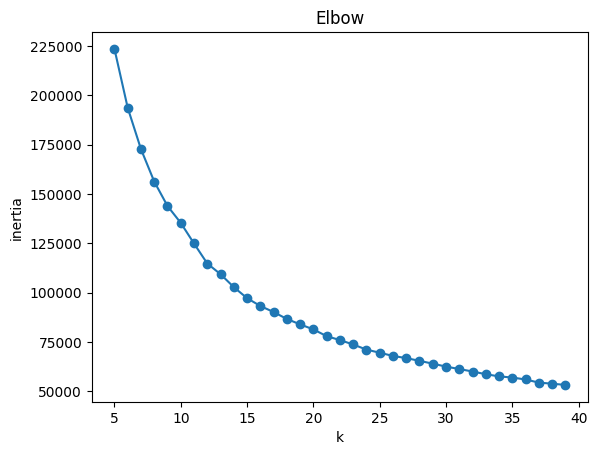

In [12]:
elbow_kmeans(range(5,40), X)

In [13]:
k = 17
km = KMeans(n_clusters=k, random_state=21)
labels = km.fit_predict(X)

In [14]:
df_clusters = df.copy()
df_clusters['cluster_baseline'] = labels

In [15]:
df_clusters.to_csv(DATASETS_DIR / "regression.csv")

In [16]:
y = df_clusters['speed']

print("type:", type(y.iloc[0]), "example:", y.iloc[0])
print("count:", len(y))
print("min, 25%, median, mean, 75%, max:", np.percentile(y, [0,25,50,75,100]))
print("mean, std:", y.mean(), y.std())
print("zeros:", (y==0).sum(), "fraction zeros:", (y==0).mean())

type: <class 'numpy.float64'> example: 0.0201999999999999
count: 160896
min, 25%, median, mean, 75%, max: [7.11635117e-07 6.06000000e-03 1.21200000e-02 1.81800000e-02
 4.45410000e+00]
mean, std: 0.014706740764354027 0.031630905288608555
zeros: 0 fraction zeros: 0.0


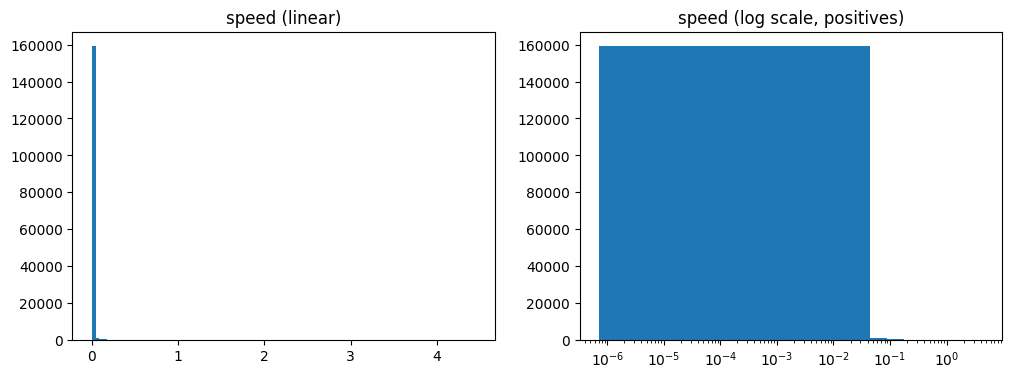

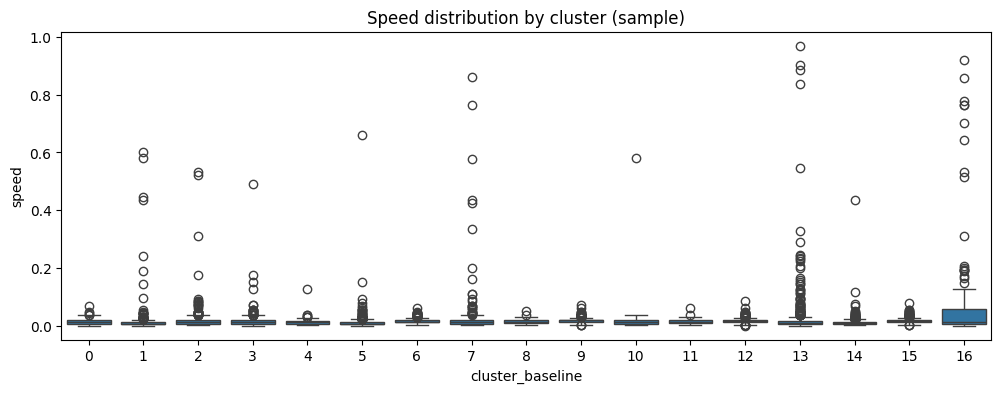

                  count      mean    median       std
cluster_baseline                                     
0                 18812  0.012451  0.012120  0.005846
1                  3456  0.012546  0.006060  0.039981
2                  8542  0.014142  0.012120  0.019810
3                 15092  0.012468  0.012120  0.012223
4                  3474  0.012983  0.012120  0.021492
5                 11533  0.011047  0.007575  0.016621
6                 12799  0.014667  0.012120  0.007000
7                  4367  0.019846  0.011018  0.064723
8                  5837  0.012904  0.012120  0.005933
9                 11322  0.016129  0.015150  0.010670
10                  520  0.023101  0.012120  0.083864
11                17998  0.012587  0.012120  0.005667
12                16312  0.015770  0.015150  0.006408
13                 7929  0.018632  0.009090  0.080088
14                 9815  0.011370  0.009090  0.014472
15                11732  0.016579  0.017044  0.007355
16                 1356  0.0

In [17]:
# histogram (log scale + linear)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(y, bins=100)
plt.title("speed (linear)")
plt.subplot(1,2,2)
plt.hist(y[y>0], bins=100)
plt.xscale('log')
plt.title("speed (log scale, positives)")
plt.show()

# boxplot per cluster
plt.figure(figsize=(12,4))
sns.boxplot(x='cluster_baseline', y='speed', data=df_clusters.sample(n=min(20000,len(df_clusters)), random_state=1))
plt.title("Speed distribution by cluster (sample)")
plt.show()

# cluster stats
stats = df_clusters.groupby('cluster_baseline')['speed'].agg(['count','mean','median','std']).sort_index()
print(stats.head(20))

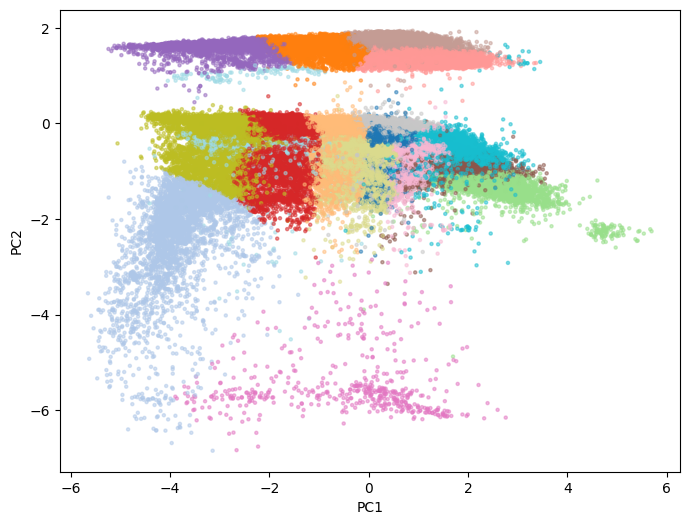

In [18]:
show_pca_2d(X, labels)

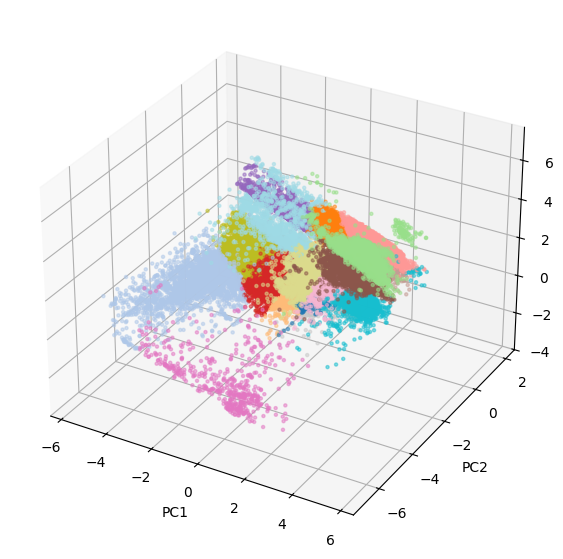

In [19]:
show_pca_3d(X, labels)

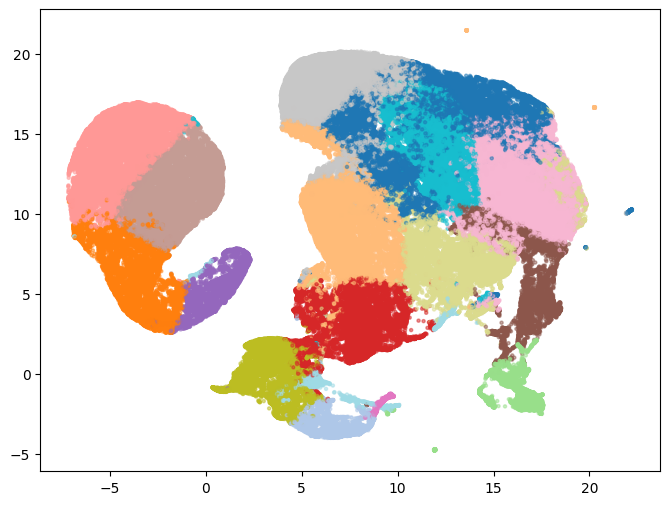

In [20]:
show_umap_2d(X, labels)

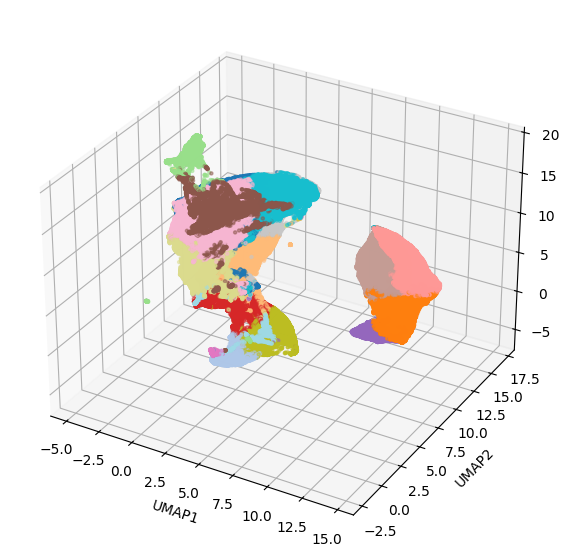

In [21]:
show_umap_3d(X, labels)

# гипотезы

## полезность `depth`

In [22]:
from scipy.stats import f_oneway

groups = [df_clusters[df_clusters['cluster_baseline']==i]['depth'] for i in range(k)]
f_stat, p_val = f_oneway(*groups)
p_val

np.float64(0.0)

In [23]:
df_clusters.groupby('cluster_baseline')['depth'].median().sort_values()

cluster_baseline
1      0.96960
7      1.75740
13     1.84830
5      3.60570
3      5.09040
12     5.27220
2      5.60550
9      6.63570
10     7.96890
0     10.30200
15    13.11990
14    14.42280
6     14.96820
11    16.08930
16    17.74065
8     22.96740
4     37.23870
Name: depth, dtype: float64

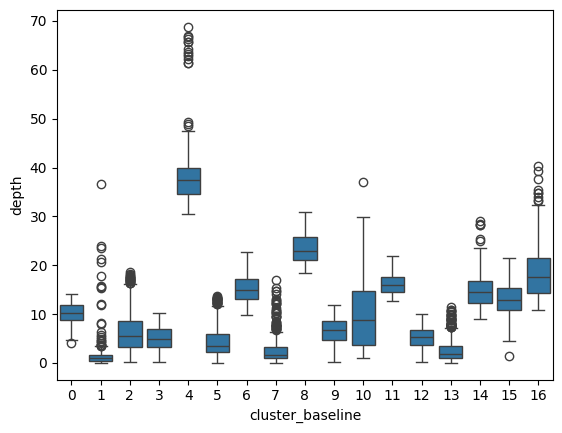

In [24]:
sns.boxplot(x='cluster_baseline', y='depth', data=df_clusters.sample(20000))
plt.show()

Включение признака `depth` сильно повлияло на результат кластеризации: кластеры в основном отражают диапазоны глубины, а не физические режимы работы установки. Это подтверждается медианой глубины по кластерам и ANOVA (p<0.001). Для более точного выявления режимов оборудования в дальнейшем можно провести кластеризацию без depth или использовать методы, чувствительные к распределению признаков, а не только масштабу.

# tune

In [25]:
X_wo_depth = df[features].drop(columns=['depth'])
X_wo_depth_scaled = scaler.fit_transform(X_wo_depth)

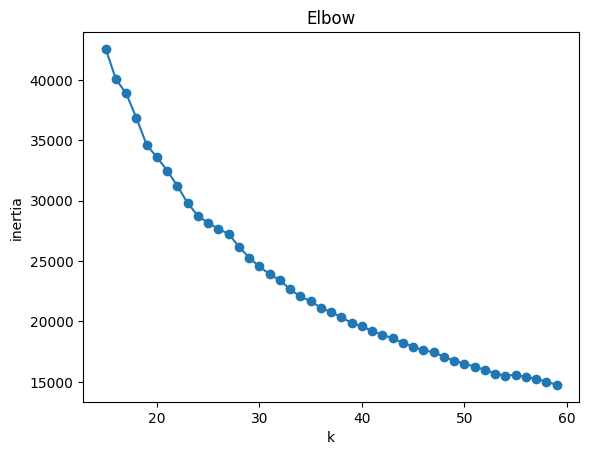

In [26]:
elbow_kmeans(range(15,60), X_wo_depth_scaled)

In [27]:
k = 30
km = KMeans(n_clusters=k, random_state=21)
labels = km.fit_predict(X_wo_depth_scaled)

In [28]:
df_clusters['cluster_no_depth'] = labels

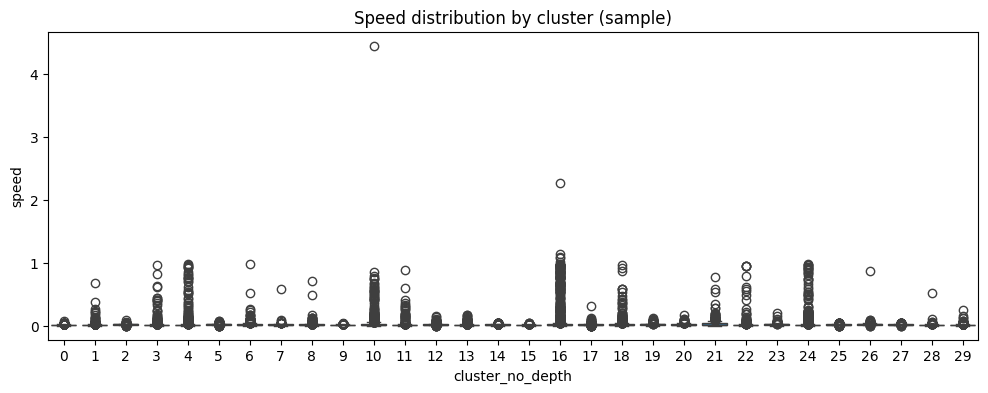

In [29]:
# boxplot per cluster
plt.figure(figsize=(12,4))
sns.boxplot(x='cluster_no_depth', y='speed', data=df_clusters)
plt.title("Speed distribution by cluster (sample)")
plt.show()

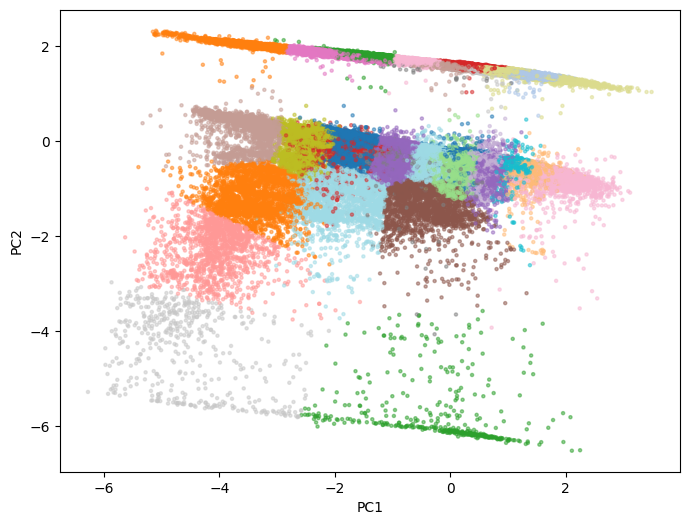

In [30]:
show_pca_2d(X_wo_depth_scaled, labels)


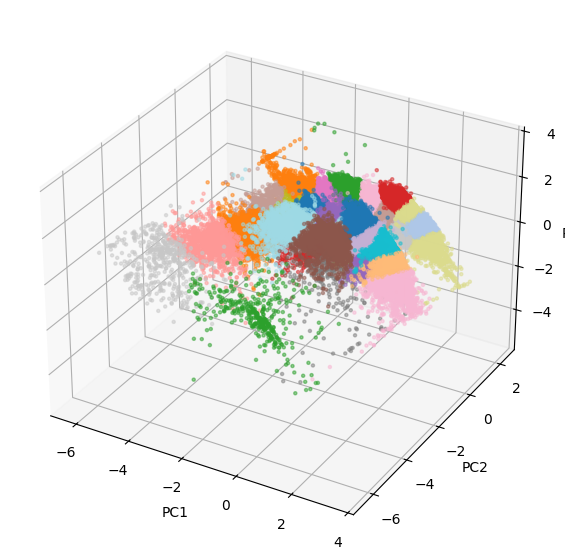

In [31]:
show_pca_3d(X_wo_depth_scaled, labels)

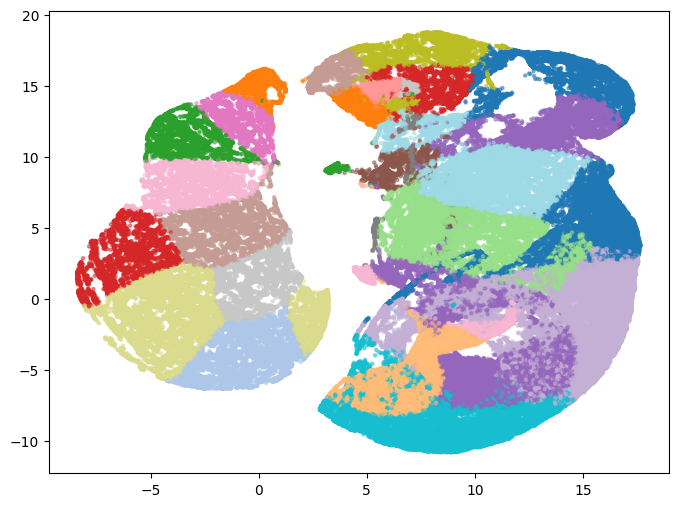

In [32]:
show_umap_2d(X_wo_depth_scaled, labels)

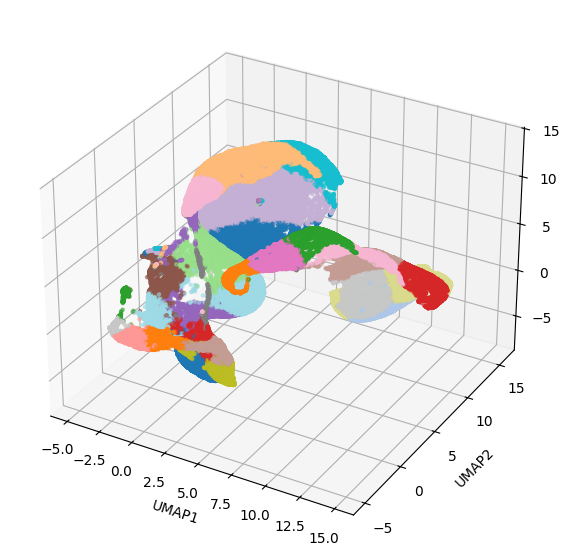

In [33]:
show_umap_3d(X_wo_depth_scaled, labels)